## Lendo o arquivo de distancias

In [1]:
import json
import pandas as pd

distances_file_name = "distances_1_4.json"

In [2]:
with open(distances_file_name, "r") as f:
    distances = json.load(f)

## Calculando a média de cada distância

In [3]:
distances_df = pd.DataFrame(distances)
distances_df.head()

,file_name,fft_distance,stft_distance,log_mel_spectrogram_distance_raw,log_mel_spectrogram_distance_normalized,log_mel_num_elements
0,keyboard_electronic_001-040-075.wav,9948.484375,1779.214111,114.662056,0.007110,16128
1,keyboard_synthetic_000-047-050.wav,10247.453125,2115.338135,168.501099,0.010448,16128
2,vocal_acoustic_000-060-050.wav,15526.680664,2716.633789,159.194611,0.009871,16128
3,brass_acoustic_006-042-075.wav,12242.626953,1927.056030,139.225311,0.008633,16128
4,keyboard_electronic_078-044-100.wav,10234.739258,1144.096313,100.168060,0.006211,16128


In [4]:
# Médias e desvios das métricas
mean_fft = distances_df['fft_distance'].mean()
std_fft = distances_df['fft_distance'].std()

mean_stft = distances_df['stft_distance'].mean()
std_stft = distances_df['stft_distance'].std()

mean_logmel_raw = distances_df['log_mel_spectrogram_distance_raw'].mean()
std_logmel_raw = distances_df['log_mel_spectrogram_distance_raw'].std()

mean_logmel_norm = distances_df['log_mel_spectrogram_distance_normalized'].mean()
std_logmel_norm = distances_df['log_mel_spectrogram_distance_normalized'].std()

print(f"Média FFT: {mean_fft}")
print(f"Desvio padrão FFT: {std_fft}")
print(f"Média STFT: {mean_stft}")
print(f"Desvio padrão STFT: {std_stft}")
print(f"Média Log Mel (raw): {mean_logmel_raw}")
print(f"Desvio padrão Log Mel (raw): {std_logmel_raw}")
print(f"Média Log Mel (normalizado): {mean_logmel_norm}")
print(f"Desvio padrão Log Mel (normalizado): {std_logmel_norm}")

Média FFT: 12649.92015081644
Desvio padrão FFT: 6208.1490287631905
Média STFT: 2366.424271658063
Desvio padrão STFT: 1132.1519364187118
Média Log Mel (raw): 138.73171847965568
Desvio padrão Log Mel (raw): 47.01335227330913
Média Log Mel (normalizado): 0.008601917068119747
Desvio padrão Log Mel (normalizado): 0.0029150144004996036


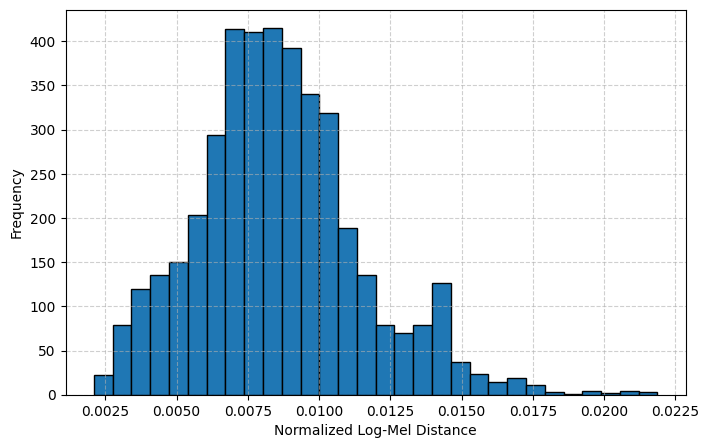

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o JSON salvo
distances_df = pd.read_json(distances_file_name)

# histograma da métrica log-mel normalizada
plt.figure(figsize=(8, 5))
plt.hist(
    distances_df["log_mel_spectrogram_distance_normalized"],
    bins=30,
    edgecolor="black"
)
# plt.title("Distribuição das distâncias Log-Mel normalizadas")
plt.xlabel("Normalized Log-Mel Distance")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


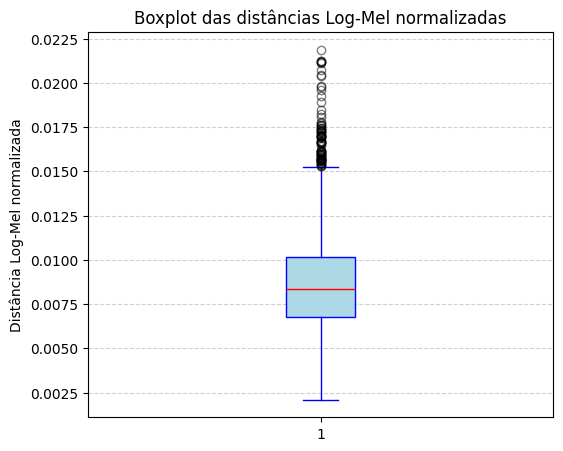

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# carregar o JSON salvo
distances_df = pd.read_json(distances_file_name)

# boxplot da métrica log-mel normalizada
plt.figure(figsize=(6, 5))
plt.boxplot(
    distances_df["log_mel_spectrogram_distance_normalized"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="blue"),
    capprops=dict(color="blue"),
    flierprops=dict(marker="o", color="gray", alpha=0.5),
)
plt.title("Boxplot das distâncias Log-Mel normalizadas")
plt.ylabel("Distância Log-Mel normalizada")
plt.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.show()


In [7]:
import pandas as pd

# carregar JSON salvo
distances_df = pd.read_json(distances_file_name)

# estatísticas descritivas para a métrica log-mel normalizada
summary_stats = {
    "mean": distances_df["log_mel_spectrogram_distance_normalized"].mean(),
    "std": distances_df["log_mel_spectrogram_distance_normalized"].std(),
    "min": distances_df["log_mel_spectrogram_distance_normalized"].min(),
    "p25": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.25),
    "median": distances_df["log_mel_spectrogram_distance_normalized"].median(),
    "p75": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.75),
    "p90": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.90),
    "p95": distances_df["log_mel_spectrogram_distance_normalized"].quantile(0.95),
    "max": distances_df["log_mel_spectrogram_distance_normalized"].max(),
}

summary_df = pd.DataFrame(summary_stats, index=["log_mel_norm"])
print(summary_df.T)


        log_mel_norm
mean        0.008602
std         0.002915
min         0.002095
p25         0.006755
median      0.008381
p75         0.010171
p90         0.012499
p95         0.014111
max         0.021872


## Calculate grouped metrics

In [8]:
import pandas as pd

# criar coluna de grupo pela primeira palavra do file_name
distances_df["group"] = distances_df["file_name"].str.split("_").str[0]

# calcular estatísticas por grupo
group_stats = distances_df.groupby("group").agg(
    mean_fft=("fft_distance", "mean"),
    mean_stft=("stft_distance", "mean"),
    mean_logmel_raw=("log_mel_spectrogram_distance_raw", "mean"),
    mean_logmel_norm=("log_mel_spectrogram_distance_normalized", "mean"),
    std_fft=("fft_distance", "std"),
    std_stft=("stft_distance", "std"),
    std_logmel_raw=("log_mel_spectrogram_distance_raw", "std"),
    std_logmel_norm=("log_mel_spectrogram_distance_normalized", "std"),
)

print(group_stats)

              mean_fft    mean_stft  mean_logmel_raw  mean_logmel_norm  \
group                                                                    
bass      11232.735153  2144.317863       135.610042          0.008408   
brass     14371.068428  2682.949540       167.617059          0.010393   
flute     14611.274208  2872.684941       141.818745          0.008793   
guitar     9692.000138  1867.466140       119.852639          0.007431   
keyboard   9619.257635  1772.917416       119.528839          0.007411   
mallet     8085.798740  1632.453959       120.609914          0.007478   
organ     18360.101282  3453.125214       166.433473          0.010320   
reed      12740.034375  2267.079281       140.700914          0.008724   
string    12883.688003  2390.650791       139.365398          0.008641   
vocal     31028.909256  5271.256375       212.646427          0.013185   

              std_fft     std_stft  std_logmel_raw  std_logmel_norm  
group                                    